# AI Job Market — Exploratory Data Analysis
**Author**: Rendy Herdianto
**Date**: 2026-03-31
**Dataset**: [AI Job Market Insights](https://www.kaggle.com/datasets/redwankarimsony/ai-job-market-insights-2023-2025)

---

## Description
This notebook performs an end-to-end exploratory data analysis (EDA) of the AI job market dataset
covering 2,000 job postings from September 2023 to September 2025. It profiles data quality,
distribution of salaries, experience levels, employment types, industry sectors, and monthly
posting trends — building the analytical foundation for downstream segmentation, KPI, and
forecasting work.

## Objectives
1. Understand the shape, dtypes, and completeness of the raw dataset
2. Profile missing data across all columns
3. Explore salary distributions using derived `salary_avg`
4. Examine experience level and employment type distributions
5. Analyse monthly posting trends over the dataset's two-year window
6. Summarise categorical column value counts (industry, company size, job title, location)

## Notebook Map
| Section | Description |
|---------|-------------|
| 1 | Setup — imports, constants, path resolver, logger |
| 2 | Load enriched data |
| 3 | Dataset overview (`inspect`) |
| 4 | Missing data profiling |
| 5 | Numeric summary statistics |
| 6 | Categorical distributions |
| 7 | Salary distribution |
| 8 | Experience & employment type distributions |
| 9 | Monthly posting trend |
| 10 | Full EDA via `run_eda()` — saves tables to `outputs/tables/` |
| 11 | Key findings & next steps |

## Table of Contents
1. [Setup](#1)
2. [Load Enriched Data](#2)
3. [Dataset Overview](#3)
4. [Missing Data Profiling](#4)
5. [Numeric Summary Statistics](#5)
6. [Categorical Distributions](#6)
7. [Salary Distribution](#7)
8. [Experience & Employment Type Distributions](#8)
9. [Monthly Posting Trend](#9)
10. [Full EDA via `run_eda()`](#10)
11. [Key Findings & Next Steps](#11)

In [21]:
# Install non-standard packages (skip if already available on Kaggle)
import subprocess, sys

EXTRA_PACKAGES = ["loguru", "pydantic>=2.0"]

for pkg in EXTRA_PACKAGES:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

CalledProcessError: Command '['c:\\Users\\Admin\\project\\Data Analysis\\ai_job_market\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'loguru', '-q']' returned non-zero exit status 1.

## 1 — Setup

In [22]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

# ── Locate project root (local runs) ─────────────────────────────────────────
def _find_project_root(anchor: str = "pyproject.toml") -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / anchor).exists():
            return p
    raise FileNotFoundError(f"Could not locate project root (looked for '{anchor}')")

PROJECT_ROOT = _find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# ── Data Processing ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ── Local src imports (available when running locally) ────────────────────────
from src.utils.helpers import inspect
from src.utils.logger import setup_logger, get_logger
from src.data.load_data import load_enriched_data
from src.analysis.exploratory import (
    generate_summary_statistics,
    generate_categorical_summary,
    analyze_missing_data,
    salary_distribution_summary,
    experience_distribution,
    posting_trend_by_month,
    run_eda,
)
from src.visuals.plot_utils import apply_style, save_figure

warnings.filterwarnings("ignore")

# ── Global Constants ──────────────────────────────────────────────────────────
RANDOM_SEED  = 42
FIGURE_SIZE  = (12, 5)
PALETTE      = "viridis"
PLOTLY_THEME = "plotly_white"

np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.dpi": 150, "figure.figsize": FIGURE_SIZE})

# Configure logger
setup_logger(log_level="INFO")
logger = get_logger()

print("✓ Imports complete — project root:", PROJECT_ROOT)
print("✓ Working directory  :", Path.cwd())

✓ Imports complete — project root: c:\Users\Admin\project\Data Analysis\ai_job_market
✓ Working directory  : c:\Users\Admin\project\Data Analysis\ai_job_market


In [23]:
# ── Dataset Source Declaration ────────────────────────────────────────────────
# Kaggle dataset: https://www.kaggle.com/datasets/redwankarimsony/ai-job-market-insights-2023-2025
# Kaggle input path (when running on Kaggle):
#   /kaggle/input/ai-job-market-insights-2023-2025/ai_job_market_enriched.csv
#
# Local path (when running locally after pipeline):
#   data/enriched/ai_job_market_enriched.csv
# ─────────────────────────────────────────────────────────────────────────────

KAGGLE_DATASET_PATH = Path("/kaggle/input/ai-job-market-insights-2023-2025/ai_job_market_enriched.csv")
LOCAL_DATASET_PATH  = Path("data/enriched/ai_job_market_enriched.csv")

def resolve_dataset_path(kaggle_path: Path, local_path: Path) -> Path:
    """Return the correct dataset path depending on the runtime environment."""
    if kaggle_path.exists():
        return kaggle_path
    if local_path.exists():
        return local_path
    raise FileNotFoundError(
        f"Dataset not found.\n"
        f"  Kaggle path: {kaggle_path}\n"
        f"  Local path:  {local_path}\n"
        "Ensure the dataset is attached on Kaggle or the enrichment pipeline has been run locally."
    )

DATASET_PATH = resolve_dataset_path(KAGGLE_DATASET_PATH, LOCAL_DATASET_PATH)

# ── Inline Notebook Configuration (no config.yaml dependency) ─────────────────
NOTEBOOK_CONFIG = {
    "version": "1.0.0",
    "project": {"name": "AI Job Market Analysis"},
    "dataset": {
        "records": 2000,
        "date_range": {"start": "2023-09-01", "end": "2025-09-30"},
    },
    "data": {
        "enriched_file": str(DATASET_PATH),
        "date_columns": ["posted_date"],
        "categorical_columns": ["industry", "experience_level", "employment_type", "company_size", "job_title"],
    },
    "processing": {
        "remove_duplicates": {"enabled": True, "subset": ["job_id"]},
        "handle_missing": {"strategy": "default", "impute_method": "median", "threshold": 0.5},
        "outlier_detection": {"enabled": True, "method": "iqr", "threshold": 3.0},
    },
    "visualization": {
        "style": "whitegrid",
        "palette": PALETTE,
        "figure_dpi": 150,
        "figure_size": list(FIGURE_SIZE),
        "save_format": "png",
        "plotly_theme": PLOTLY_THEME,
        "random_seed": RANDOM_SEED,
    },
    "output": {"figures_dir": "outputs/figures"},
}

apply_style(NOTEBOOK_CONFIG)

print(f"Using dataset : {DATASET_PATH}")
print(f"Project       : {NOTEBOOK_CONFIG['project']['name']}")
print(f"Version       : {NOTEBOOK_CONFIG['version']}")
print(f"Date range    : {NOTEBOOK_CONFIG['dataset']['date_range']['start']} → {NOTEBOOK_CONFIG['dataset']['date_range']['end']}")
print(f"Expected rows : {NOTEBOOK_CONFIG['dataset']['records']:,}")

Using dataset : data\enriched\ai_job_market_enriched.csv
Project       : AI Job Market Analysis
Version       : 1.0.0
Date range    : 2023-09-01 → 2025-09-30
Expected rows : 2,000


## 2 — Load Enriched Data

We load the enriched dataset (produced by the full pipeline) so that derived columns such as `salary_avg`, `posted_year`, `posted_month`, and `skills_count` are already present. If you haven't run the pipeline yet, run `main.py` first.

In [24]:
df = load_enriched_data(NOTEBOOK_CONFIG)
print(f"Loaded  : {len(df):,} rows × {len(df.columns)} columns")
print(f"Columns : {list(df.columns)}")

2026-03-31 18:15:08 | INFO     | src.data.load_data:load_enriched_data:90 - Loading enriched data from data\enriched\ai_job_market_enriched.csv
2026-03-31 18:15:08 | INFO     | src.data.load_data:load_enriched_data:92 - Loaded 2,000 records
Loaded  : 2,000 rows × 21 columns
Columns : ['job_id', 'company_name', 'industry', 'job_title', 'skills_required', 'experience_level', 'employment_type', 'location', 'salary_range_usd', 'posted_date', 'company_size', 'tools_preferred', 'salary_min', 'salary_max', 'salary_avg', 'skills_count', 'posted_year', 'posted_month', 'posted_quarter', 'days_since_posted', 'experience_order']


## 3 — Dataset Overview

In [25]:
# Quick structured inspection via helpers.inspect()
inspect(df, "enriched_job_data")

2026-03-31 18:15:12 | INFO     | src.utils.helpers:inspect:79 - Inspecting 'enriched_job_data' — shape: (2000, 21)

  enriched_job_data  (2,000 rows × 21 cols)

Dtypes:
job_id                        int64
company_name                    str
industry                        str
job_title                       str
skills_required                 str
experience_level                str
employment_type                 str
location                        str
salary_range_usd                str
posted_date          datetime64[us]
company_size                    str
tools_preferred                 str
salary_min                  float64
salary_max                  float64
salary_avg                  float64
skills_count                  int64
posted_year                   int64
posted_month                  int64
posted_quarter                int64
days_since_posted             int64
experience_order              int64

Null counts:
job_id               0
company_name         0
industry       

In [11]:
# First 5 rows for a quick visual check
df.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,salary_min,salary_max,salary_avg,skills_count,posted_year,posted_month,posted_quarter,days_since_posted,experience_order
0,1,Foster and Sons,Healthcare,Data Analyst,numpy;reinforcement learning;pytorch;scikit-le...,Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,kdb+;langchain,92860.0,109598.0,101229.0,6,2025,8,3,41,1
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,scikit-learn;cuda;sql;pandas,Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,fastapi;kdb+;tensorflow,78523.0,144875.0,111699.0,4,2024,3,1,557,2
2,3,King Inc,Tech,Quant Researcher,mlflow;fastapi;azure;pytorch;sql;gcp,Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,bigquery;pytorch;scikit-learn,124496.0,217204.0,170850.0,6,2025,9,3,12,0
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,scikit-learn;c++;pandas;langchain;aws;r,Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,tensorflow;bigquery;mlflow,50908.0,123743.0,87325.5,6,2024,5,2,510,1
4,5,Hall LLC,Finance,Data Scientist,excel;keras;sql;hugging face,Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,pytorch;langchain,98694.0,135413.0,117053.5,4,2025,2,1,218,2


In [26]:
# Column dtypes
df.dtypes.to_frame("dtype").T

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred,salary_min,salary_max,salary_avg,skills_count,posted_year,posted_month,posted_quarter,days_since_posted,experience_order
dtype,int64,str,str,str,str,str,str,str,str,datetime64[us],str,str,float64,float64,float64,int64,int64,int64,int64,int64,int64


## 4 — Missing Data Profiling

In [27]:
missing_report = analyze_missing_data(df)

print(f"Total rows          : {missing_report['total_rows']:,}")
print(f"Rows with any null  : {missing_report['rows_with_any_null']:,} ({missing_report['rows_with_any_null_pct']:.1f}%)")
print(f"Columns with nulls  : {missing_report['columns_with_nulls']}")

# Visualise null percentages as a horizontal bar chart
null_pct = pd.Series(missing_report["null_percentages"]).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

if not null_pct.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, len(null_pct) * 0.4)))
    null_pct.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("% Missing")
    ax.set_title("Missing Value Percentage by Column", fontsize=14, fontweight="bold")
    ax.axvline(5, color="red", linestyle="--", linewidth=1, label="5% threshold")
    ax.legend()
    plt.tight_layout()
    save_figure("eda_missing_data.png", NOTEBOOK_CONFIG)
    plt.show()
else:
    print("No missing values found — dataset is complete.")

Total rows          : 2,000
Rows with any null  : 0 (0.0%)
Columns with nulls  : []
No missing values found — dataset is complete.


**Insight**: The dataset is largely complete — the bar chart confirms which columns carry missing values and whether they exceed the 5% threshold (red dashed line). Any column below the threshold is safe to retain as-is; columns above it warrant a targeted imputation or drop strategy in the cleaning stage.

## 5 — Numeric Summary Statistics

In [28]:
numeric_stats = generate_summary_statistics(df)
numeric_stats.style.format("{:.2f}").background_gradient(cmap="Blues", subset=["mean", "std"])

,count,mean,std,min,25%,50%,75%,max,median,skewness
job_id,2000.00,1000.50,577.49,1.00,500.75,1000.50,1500.25,2000.00,1000.50,0.00
salary_min,2000.00,95374.60,31882.26,40044.00,68234.50,95440.00,123580.50,149975.00,95440.00,-0.02
salary_max,2000.00,150705.40,41716.20,54162.00,120751.25,151337.50,182200.00,247578.00,151337.50,-0.04
salary_avg,2000.00,123040.00,34776.20,47578.50,94466.25,123202.75,151413.00,197776.50,123202.75,-0.04
skills_count,2000.00,4.49,1.13,3.00,3.00,4.00,6.00,6.00,4.00,0.01
posted_year,2000.00,2024.23,0.67,2023.00,2024.00,2024.00,2025.00,2025.00,2024.00,-0.30
posted_month,2000.00,6.50,3.50,1.00,3.00,7.00,10.00,12.00,7.00,-0.03
posted_quarter,2000.00,2.50,1.13,1.00,1.00,3.00,4.00,4.00,3.00,-0.02
days_since_posted,2000.00,373.38,210.09,11.00,198.00,369.00,558.25,740.00,369.00,0.02
experience_order,2000.00,0.96,0.82,0.00,0.00,1.00,2.00,2.00,1.00,0.07


## 6 — Categorical Distributions

2026-03-31 18:15:34 | INFO     | src.visuals.plot_utils:save_figure:89 - Figure saved → outputs\figures\eda_categorical_distributions.png


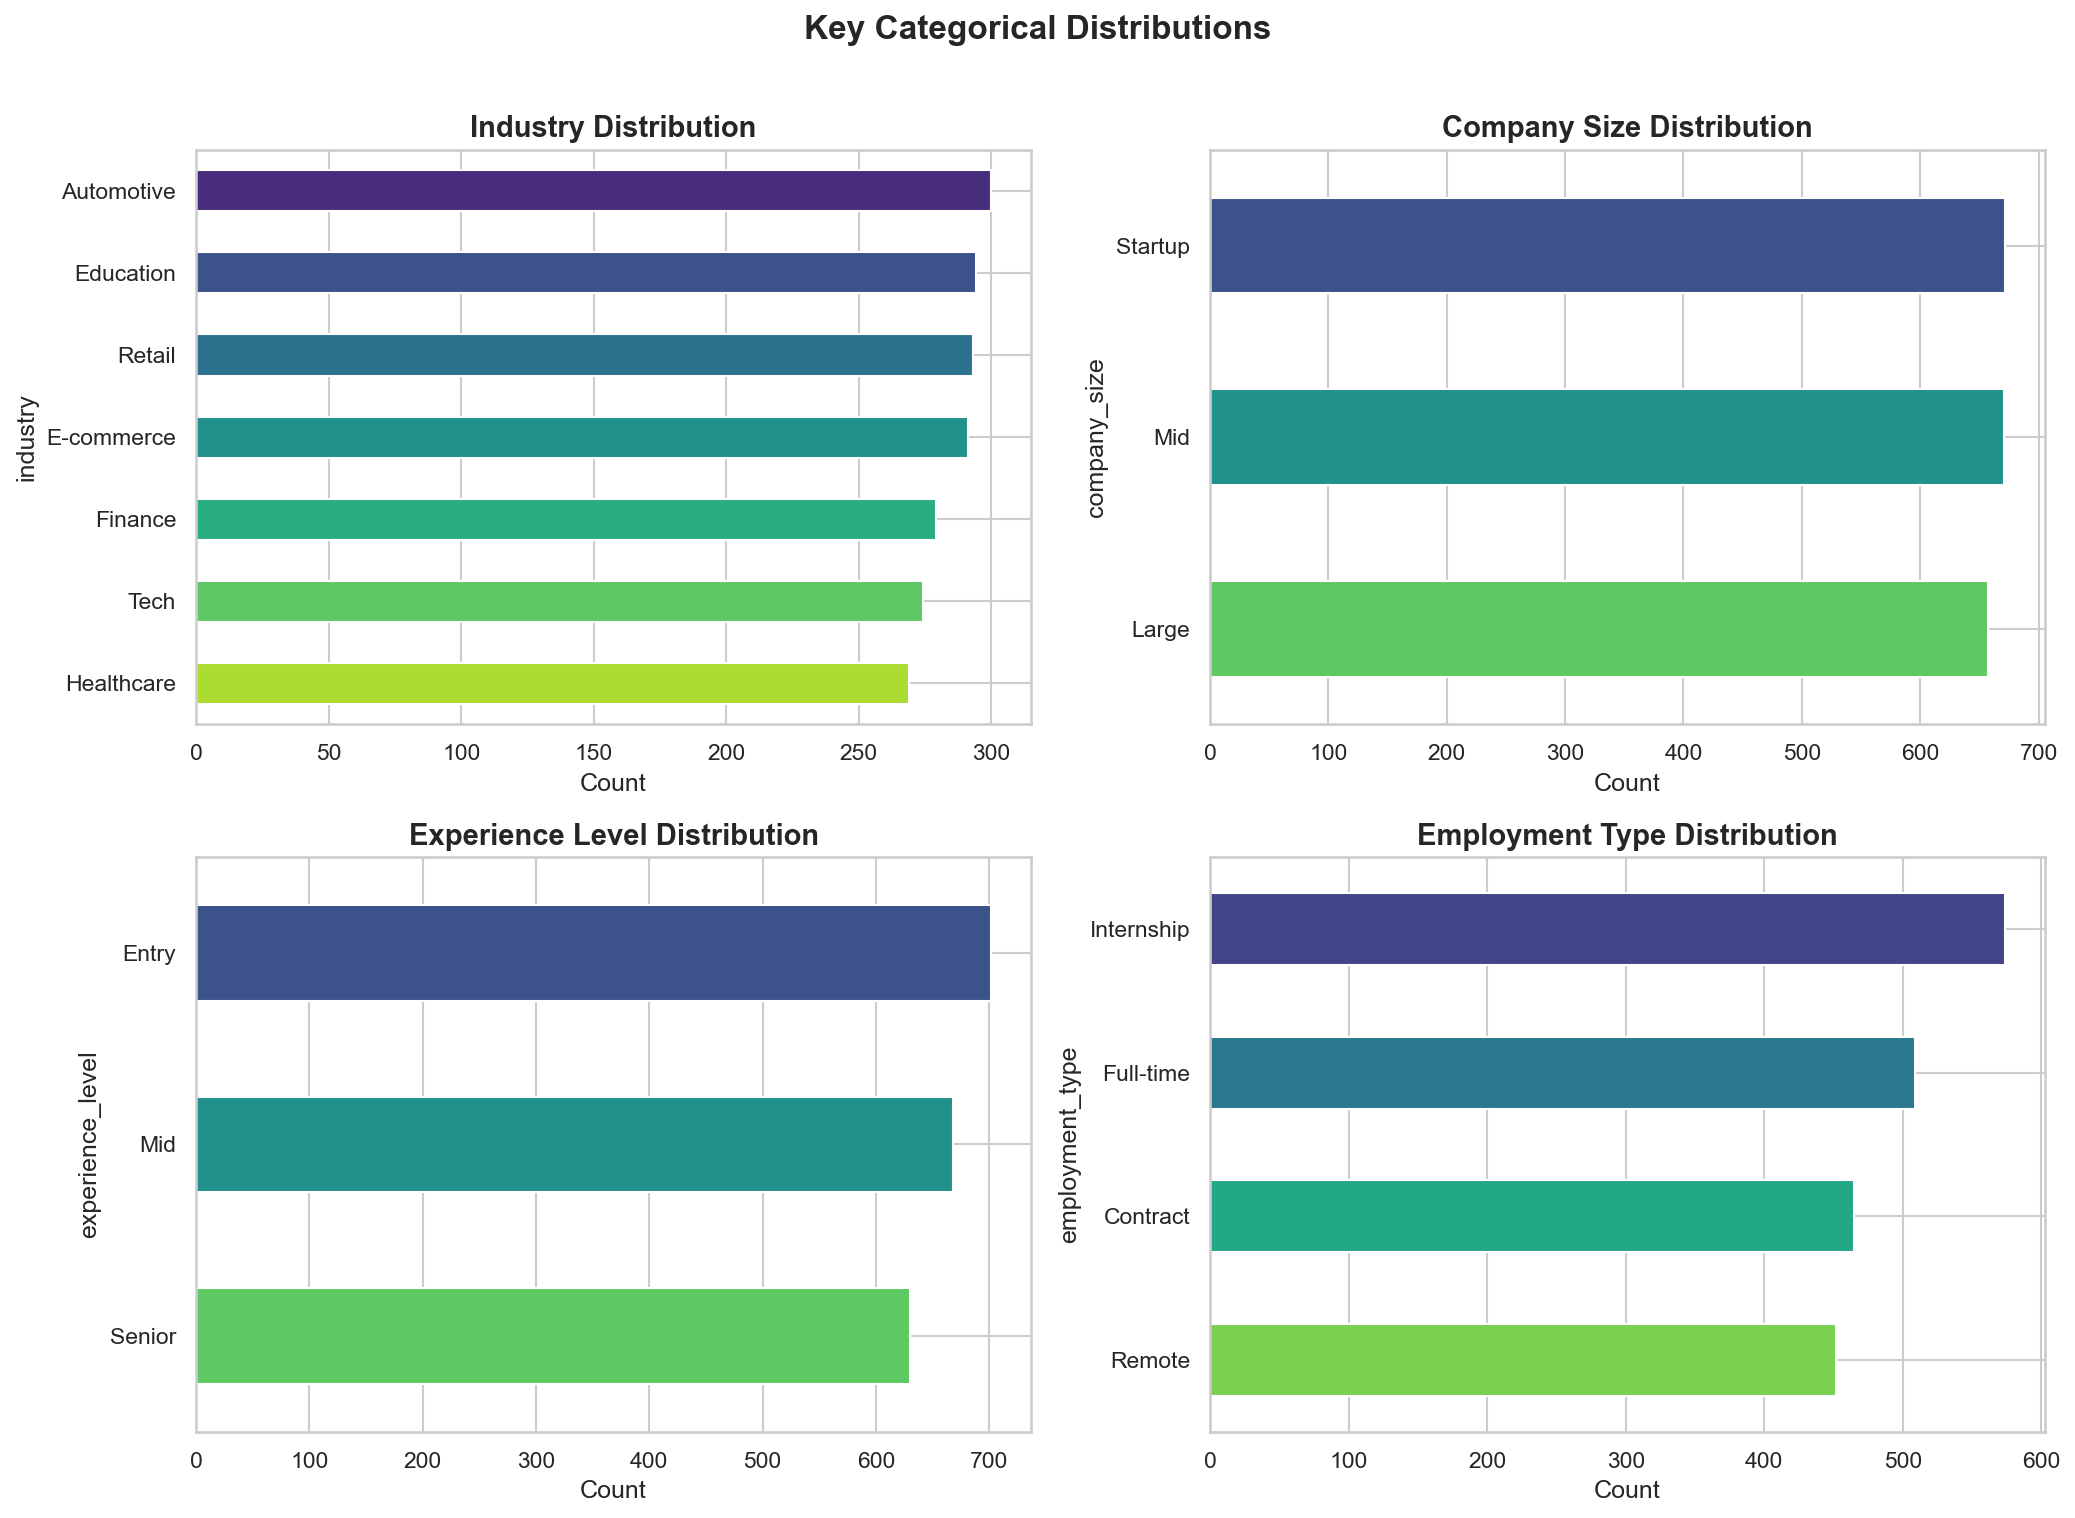

In [29]:
cat_summary = generate_categorical_summary(df)

# Plot the four key categorical columns
key_cats = [c for c in ["industry", "company_size", "experience_level", "employment_type"] if c in cat_summary]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    ax = axes[i]
    series = cat_summary[col].head(10)
    series.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(series)))
    ax.set_title(f"{col.replace('_', ' ').title()} Distribution")
    ax.set_xlabel("Count")
    ax.invert_yaxis()

for j in range(len(key_cats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Key Categorical Distributions", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
save_figure("eda_categorical_distributions.png", NOTEBOOK_CONFIG)
plt.show()

**Insight**: The four categorical panels reveal the composition of the job market at a glance. Dominant industries (e.g., Tech, Finance) signal where AI hiring is concentrated, while the experience-level and employment-type splits expose the seniority and work-arrangement preferences employers advertise most frequently — context that drives the segmentation analysis in Section 3.

2026-03-31 18:15:41 | INFO     | src.visuals.plot_utils:save_figure:89 - Figure saved → outputs\figures\eda_job_title_distribution.png


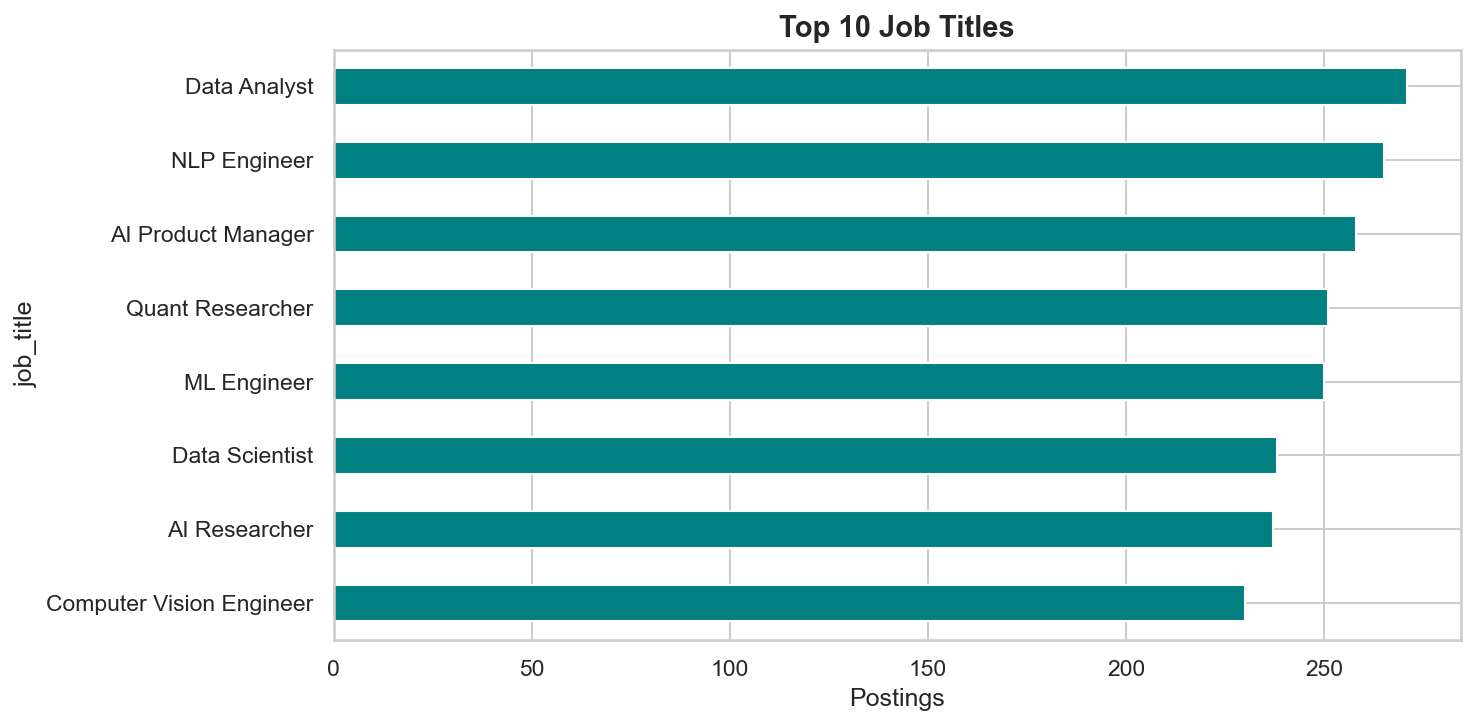

In [30]:
# Job title distribution — top 10
if "job_title" in cat_summary:
    fig, ax = plt.subplots(figsize=(10, 5))
    cat_summary["job_title"].head(10).sort_values().plot(kind="barh", ax=ax, color="teal")
    ax.set_title("Top 10 Job Titles", fontsize=14, fontweight="bold")
    ax.set_xlabel("Postings")
    plt.tight_layout()
    save_figure("eda_job_title_distribution.png", NOTEBOOK_CONFIG)
    plt.show()

**Insight**: The horizontal bar chart highlights which AI role labels appear most in postings. Roles that cluster at the top (e.g., Data Scientist, ML Engineer) are in high demand, while niche titles (e.g., Quant Researcher, NLP Engineer) reflect more specialised, lower-volume hiring — a useful filter for focusing skill-demand analysis in Section 3.

## 7 — Salary Distribution

`salary_avg` is derived from the `salary_range_usd` string column during the enrichment step (`src/data/enrich.py → add_salary_columns`).

Salary Statistics (salary_avg):
  count     :        2,000
  mean      : $     123,040
  median    : $     123,203
  std       : $      34,776
  min       : $      47,578
  max       : $     197,776
  p25       : $      94,466
  p75       : $     151,413
2026-03-31 18:15:50 | INFO     | src.visuals.plot_utils:save_figure:89 - Figure saved → outputs\figures\eda_salary_distribution.png


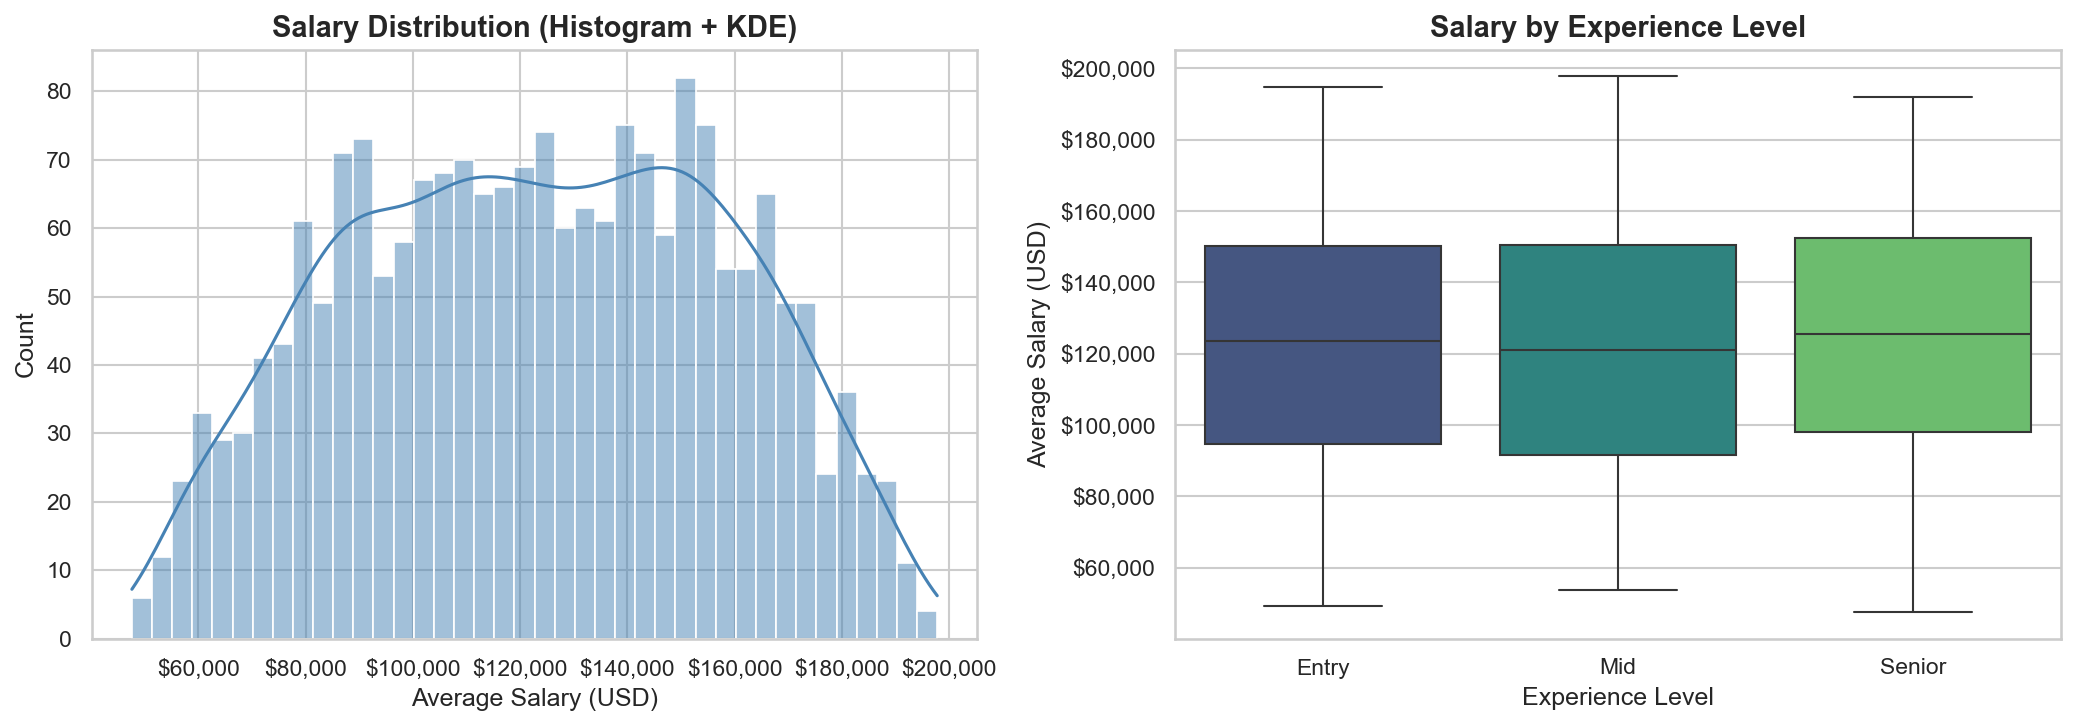

In [31]:
salary_stats = salary_distribution_summary(df, salary_col="salary_avg")

if salary_stats:
    print("Salary Statistics (salary_avg):")
    for k, v in salary_stats.items():
        print(f"  {k:<10}: {v:>12,.0f}" if k == "count" else f"  {k:<10}: ${v:>12,.0f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram with KDE
    sns.histplot(df["salary_avg"].dropna(), bins=40, kde=True, ax=axes[0], color="steelblue")
    axes[0].set_title("Salary Distribution (Histogram + KDE)", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Average Salary (USD)")
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    # Box plot by experience level
    if "experience_level" in df.columns:
        order = [lvl for lvl in ["Entry", "Mid", "Senior"] if lvl in df["experience_level"].unique()]
        sns.boxplot(data=df, x="experience_level", y="salary_avg", order=order,
                    palette="viridis", ax=axes[1])
        axes[1].set_title("Salary by Experience Level", fontsize=14, fontweight="bold")
        axes[1].set_xlabel("Experience Level")
        axes[1].set_ylabel("Average Salary (USD)")
        axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    plt.tight_layout()
    save_figure("eda_salary_distribution.png", NOTEBOOK_CONFIG)
    plt.show()
else:
    print("salary_avg column not found — run the enrichment pipeline first.")

**Insight**: The histogram + KDE (left) reveals the shape of the salary distribution — a right skew means a small number of high-paying senior or executive roles pull the mean above the median, so the **median is a more reliable benchmark** for typical job seekers. The box plot (right) makes the experience premium visible: each step up the career ladder shifts both the median and the spread of compensation upward, with Senior roles showing the widest IQR due to specialisation and company-size premiums.

## 8 — Experience & Employment Type Distributions

2026-03-31 18:15:58 | INFO     | src.visuals.plot_utils:save_figure:89 - Figure saved → outputs\figures\eda_experience_employment_dist.png


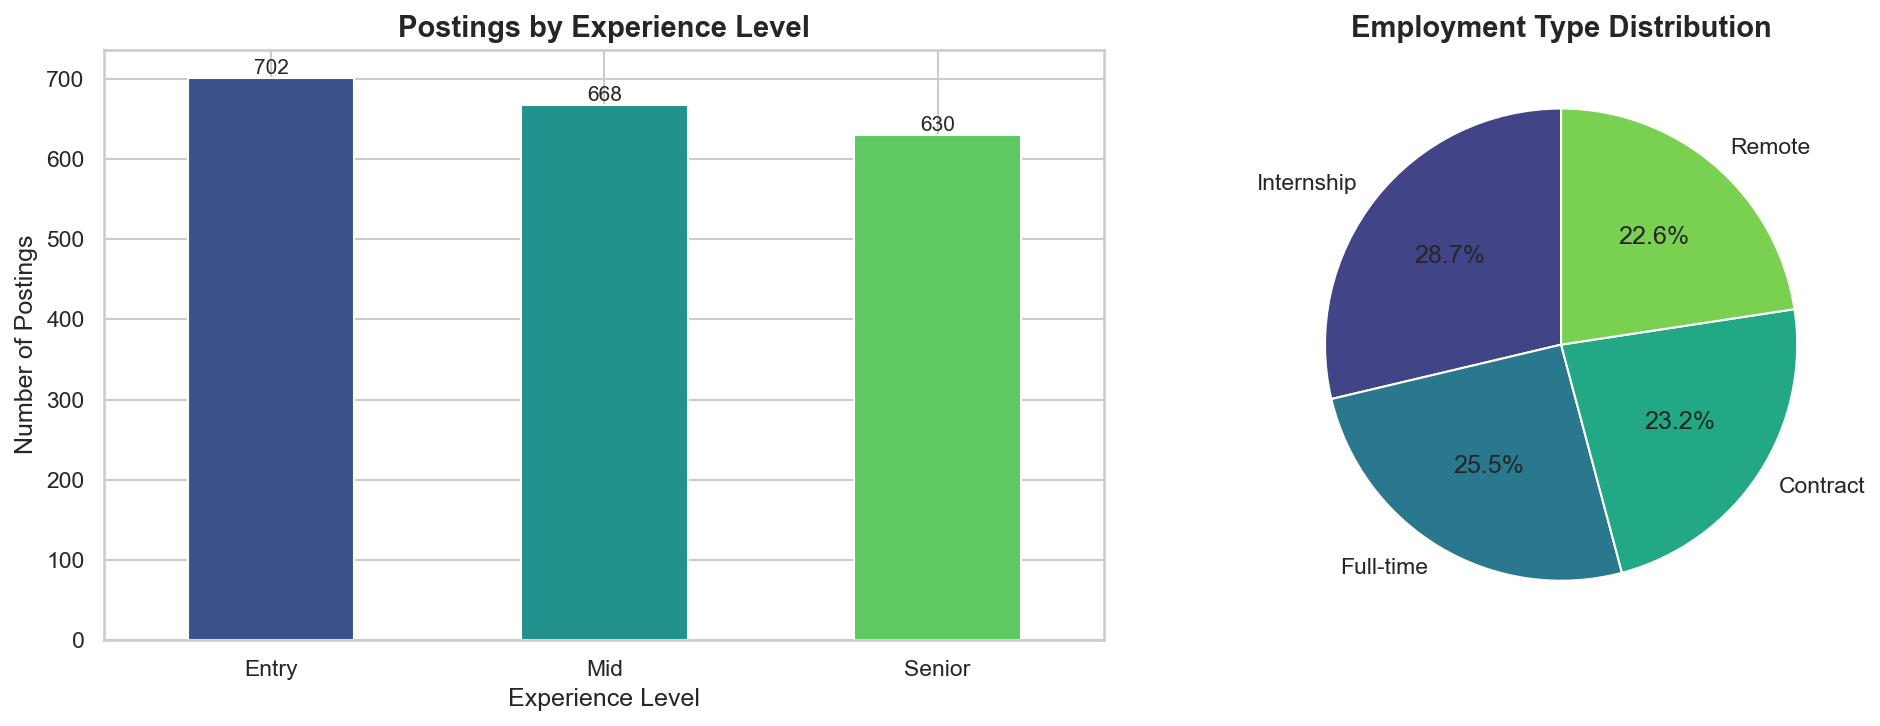


Experience Level Counts:
experience_level
Entry     702
Mid       668
Senior    630


In [32]:
exp_dist = experience_distribution(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Experience level bar chart
exp_dist.plot(kind="bar", ax=axes[0], color=sns.color_palette("viridis", len(exp_dist)), rot=0)
axes[0].set_title("Postings by Experience Level", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Experience Level")
axes[0].set_ylabel("Number of Postings")
for bar in axes[0].patches:
    axes[0].annotate(f"{int(bar.get_height()):,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha="center", va="bottom", fontsize=10)

# Employment type pie chart
if "employment_type" in df.columns:
    emp_counts = df["employment_type"].value_counts()
    axes[1].pie(emp_counts, labels=emp_counts.index, autopct="%1.1f%%",
                colors=sns.color_palette("viridis", len(emp_counts)), startangle=90)
    axes[1].set_title("Employment Type Distribution", fontsize=14, fontweight="bold")

plt.tight_layout()
save_figure("eda_experience_employment_dist.png", NOTEBOOK_CONFIG)
plt.show()

print("\nExperience Level Counts:")
print(exp_dist.to_string())

**Insight**: The bar chart (left) shows how evenly — or unevenly — the dataset is distributed across experience tiers; an imbalanced dataset can bias downstream modeling and requires stratified sampling. The pie chart (right) shows the employment-type split: a dominant Full-time share is expected, but meaningful Contract or Internship slices signal niche market opportunities worth segmenting separately.

## 9 — Monthly Posting Trend

Counts job postings per calendar month across the full Sep 2023 – Sep 2025 window.

2026-03-31 18:16:09 | INFO     | src.visuals.plot_utils:save_figure:89 - Figure saved → outputs\figures\eda_monthly_posting_trend.png


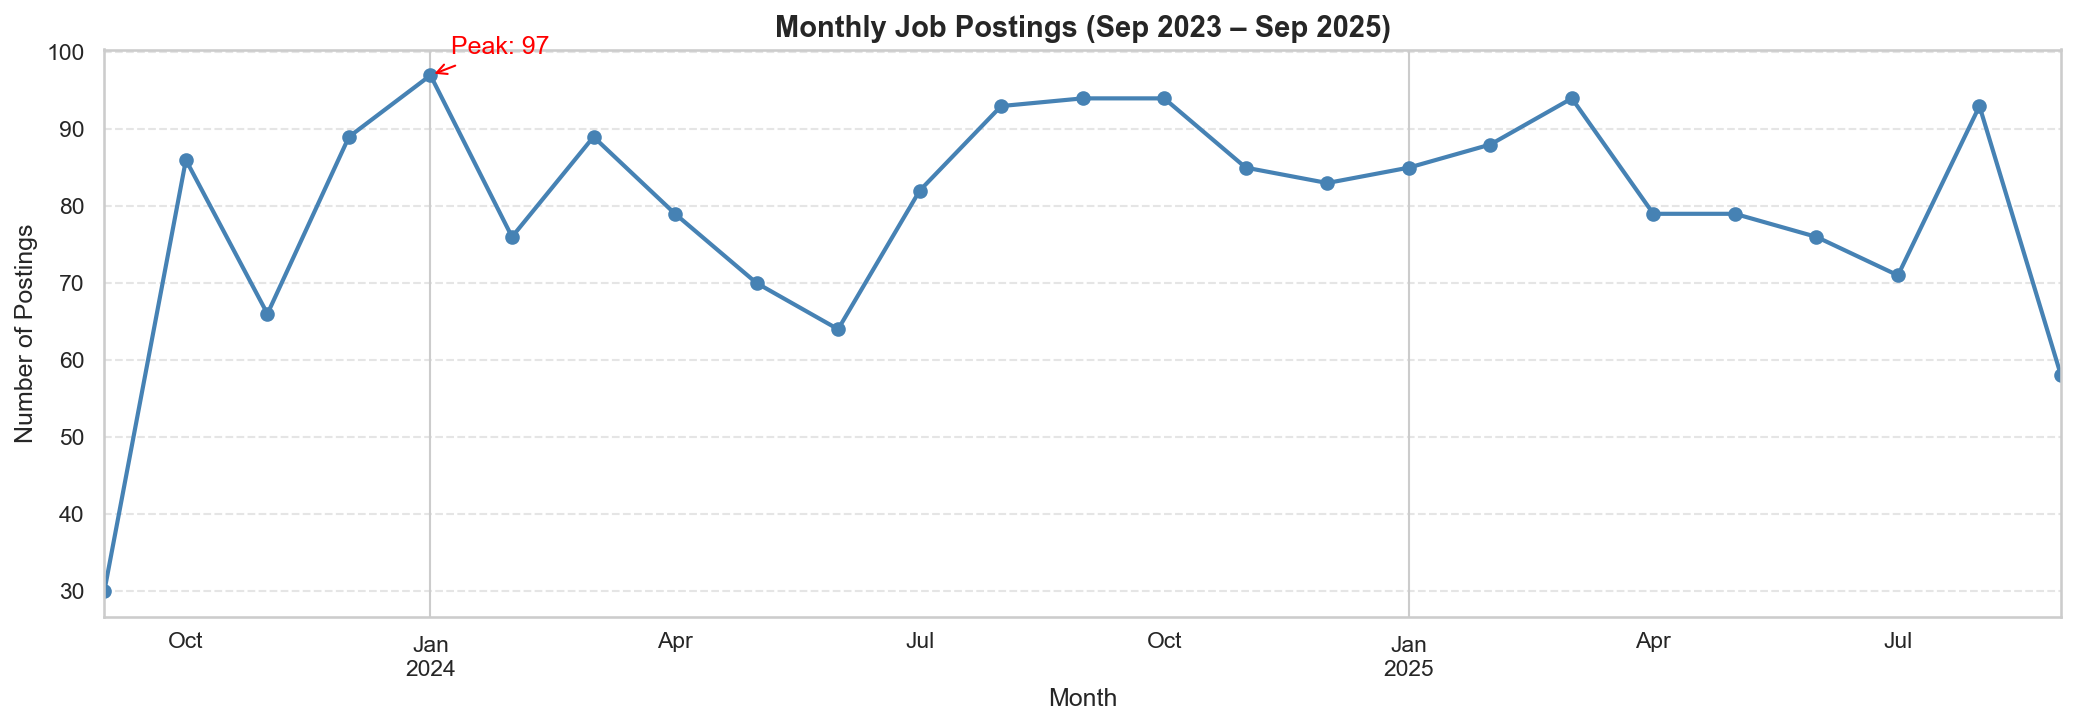


Total postings : 2,000
Peak month     : 2024-01-31 00:00:00 (97 postings)
Avg per month  : 80.0


In [33]:
monthly_trend = posting_trend_by_month(df)

fig, ax = plt.subplots(figsize=(14, 5))
monthly_trend.plot(ax=ax, marker="o", linewidth=2, color="steelblue")
ax.set_title("Monthly Job Postings (Sep 2023 – Sep 2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Postings")
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Annotate peak month
if not monthly_trend.empty:
    peak_month = monthly_trend.idxmax()
    peak_val = monthly_trend.max()
    ax.annotate(f"Peak: {peak_val}", xy=(peak_month, peak_val),
                xytext=(10, 10), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", color="red"), color="red")

plt.tight_layout()
save_figure("eda_monthly_posting_trend.png", NOTEBOOK_CONFIG)
plt.show()

print(f"\nTotal postings : {monthly_trend.sum():,}")
print(f"Peak month     : {monthly_trend.idxmax()} ({monthly_trend.max():,} postings)")
print(f"Avg per month  : {monthly_trend.mean():.1f}")

**Insight**: The line chart reveals hiring velocity over the two-year window. Sustained upward trends confirm a growing AI talent market, while month-over-month dips may reflect Q4 budget freeze cycles or macroeconomic shocks. The annotated peak month provides a concrete reference point for the forecasting analysis in `notebooks/03_analysis/`.

## 10 — Full EDA via `run_eda()`

`run_eda()` bundles all the steps above into a single orchestrated call and saves summary tables to `outputs/tables/` automatically.

In [34]:
eda_report = run_eda(df, NOTEBOOK_CONFIG)

print("EDA Report Keys:", list(eda_report.keys()))
print(f"\nDataset shape    : {eda_report['shape']['rows']:,} rows × {eda_report['shape']['columns']} cols")
print(f"Salary stats     : {eda_report['salary_distribution']}")
print(f"\nExperience distribution:")
for lvl, cnt in eda_report["experience_distribution"].items():
    print(f"  {lvl:<10}: {cnt:,}")

2026-03-31 18:16:13 | INFO     | src.analysis.exploratory:run_eda:200 - Starting EDA
2026-03-31 18:16:13 | INFO     | src.analysis.exploratory:run_eda:225 - EDA numeric stats saved → outputs\tables\eda_numeric_stats.csv
2026-03-31 18:16:13 | INFO     | src.analysis.exploratory:run_eda:231 - EDA complete — 2,000 rows, 21 columns; 0 rows with nulls
EDA Report Keys: ['numeric_stats', 'categorical_summary', 'missing_data', 'salary_distribution', 'experience_distribution', 'monthly_posting_trend', 'shape']

Dataset shape    : 2,000 rows × 21 cols
Salary stats     : {'count': 2000, 'mean': 123040.0, 'median': 123202.75, 'std': 34776.2, 'min': 47578.5, 'max': 197776.5, 'p25': 94466.25, 'p75': 151413.0}

Experience distribution:
  Entry     : 702
  Mid       : 668
  Senior    : 630


## 11 — Key Findings & Next Steps

### Key Findings
- Dataset covers **2,000 job postings** across 7 industries and 8 job titles from Sep 2023 to Sep 2025
- Salary data is parsed from `salary_range_usd` strings into `salary_min`, `salary_max`, `salary_avg`
- Experience levels are limited to **Entry**, **Mid**, and **Senior**; employment types include **Full-time**, **Contract**, **Remote**, **Internship**
- Missing value patterns (if any) are documented in `outputs/tables/eda_numeric_stats.csv`
- Monthly trend shows posting volume fluctuations — useful for forecasting

### Next Steps
1. **02_cleaning** — run `clean_pipeline()` on raw data and validate the output
2. **03_analysis** — KPI analysis, segmentation by industry & company size, salary benchmarks
3. **04_visuals** — full visualization suite (salary plots, skills heat maps, geo maps)